# Tactical-lever sensitivity: Logistic Regression vs CatBoost

This notebook reproduces **Figure 3.12** of the thesis (the "central paradox"):
for each of the four controllable levers, sweep that lever across its 5th-to-95th
training-percentile band, hold every other feature at the UTA Arad vs FCSB
baseline, and plot how far each calibrated model moves the predicted home-win
probability.

It mirrors `TheNotebook.ipynb` exactly: the 26-feature set (base columns +
yellow cards + saves + H2H, odds off), the grid-tuned and Platt-calibrated
CatBoost, the saga/C=1 calibrated Logistic Regression, and the notebook's own
`build_h2h_base_vector` baseline (the mean of the exact UTA Arad vs FCSB
fixtures).

> **Note.** Figure 3.12 and the holdout-averaged table at the bottom are regenerated here from `All_Data.csv` using the notebook's data load, feature set, models, and baseline builder, and they reproduce the numbers quoted in the thesis text (LR shots ~17pp; CatBoost roughly 6.7 / 5.6 / 5.2 / 2.8 across levers).


In [1]:
import os
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import catboost as cb

DATA_PATH = os.path.join(r"C:\Users\Mihai\OneDrive\Desktop\Facultate\Thesis\Colab", "All_Data.csv")

USE_ODDS = False
base_cols = [
    "Home_Points_5", "Away_Points_5", "Home_Goals_5", "Away_Goals_5",
    "Home_Conceded_5", "Away_Conceded_5", "Home_RestDays", "Away_RestDays",
    "Home_Poss_5", "Away_Poss_5", "Home_Shots_5", "Away_Shots_5",
    "Home_SoT_5", "Away_SoT_5", "Home_Corners_5", "Away_Corners_5",
    "Computed_Home_Elo", "Computed_Away_Elo", "Computed_HFA", "Computed_Elo_Diff",
]
optional_cols = ["Odd_Home", "Odd_Draw", "Odd_Away", "Home_YellowCards_5",
                 "Away_YellowCards_5", "Home_Saves_5", "Away_Saves_5",
                 "Home_H2H_Pts_3", "Away_H2H_Pts_3"]

final_df_with_elo = pd.read_csv(DATA_PATH)
final_df_with_elo["match_date"] = pd.to_datetime(final_df_with_elo["match_date"], errors="coerce")
final_df_with_elo = final_df_with_elo.sort_values("match_date").reset_index(drop=True)
final_df_with_elo["Target_Binary"] = (final_df_with_elo["home_score"] > final_df_with_elo["away_score"]).astype(int)

if not USE_ODDS:
    optional_cols = [c for c in optional_cols if not c.startswith("Odd_")]
feature_cols = base_cols + [c for c in optional_cols if c in final_df_with_elo.columns]
feature_idx = {col: i for i, col in enumerate(feature_cols)}

split_date = "2024-07-01"
train_df = final_df_with_elo[final_df_with_elo["match_date"] < split_date].copy()
test_df = final_df_with_elo[final_df_with_elo["match_date"] >= split_date].copy()
X_train_raw = train_df[feature_cols]
y_train = train_df["Target_Binary"]
y_test = test_df["Target_Binary"]

imputer = KNNImputer(n_neighbors=5)
imputer.fit(X_train_raw)
tscv = TimeSeriesSplit(n_splits=3)
print(f"Features: {len(feature_cols)} (odds={'on' if USE_ODDS else 'off'})  "
      f"Train: {len(train_df)}  Test: {len(test_df)}")


Features: 26 (odds=off)  Train: 1281  Test: 319


In [2]:
# Grid-tuned, Platt-calibrated CatBoost and saga/C=1 calibrated Logistic Regression
grid_cat = GridSearchCV(
    cb.CatBoostClassifier(iterations=300, random_state=42, verbose=0),
    {"depth": [3, 5], "learning_rate": [0.02, 0.05]},
    cv=tscv, scoring="neg_log_loss", n_jobs=1)
grid_cat.fit(train_df[feature_cols], y_train)
calibrated_cat = CalibratedClassifierCV(grid_cat.best_estimator_, method="sigmoid", cv=tscv)
calibrated_cat.fit(train_df[feature_cols], y_train)

lr_base = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, C=1.0, solver="saga", random_state=42)),
])
calibrated_lr = CalibratedClassifierCV(lr_base, method="sigmoid", cv=tscv)
calibrated_lr.fit(train_df[feature_cols], y_train)

print(f"CatBoost best params: {grid_cat.best_params_}")
print(f"Holdout accuracy: CatBoost {accuracy_score(y_test, calibrated_cat.predict(test_df[feature_cols]))*100:.1f}%  "
      f"LR {accuracy_score(y_test, calibrated_lr.predict(test_df[feature_cols]))*100:.1f}%")


CatBoost best params: {'depth': 3, 'learning_rate': 0.02}
Holdout accuracy: CatBoost 61.1%  LR 64.3%


In [3]:
def build_h2h_base_vector(home_team, away_team, df, feature_cols, imputer, scaler=None, n_matches=5, cutoff_date=None):
    data = df.copy()
    if cutoff_date is not None:
        data = data[data["match_date"] < cutoff_date].copy()
    exact = data[(data["home_team"] == home_team) & (data["away_team"] == away_team)].sort_values("match_date").tail(n_matches)
    reverse_fixture = data[(data["home_team"] == away_team) & (data["away_team"] == home_team)].sort_values("match_date").tail(n_matches)
    home_recent = data[data["home_team"] == home_team].sort_values("match_date").tail(n_matches)
    away_recent = data[data["away_team"] == away_team].sort_values("match_date").tail(n_matches)
    if not exact.empty:
        row = exact[feature_cols].mean()
    elif not reverse_fixture.empty:
        swapped = reverse_fixture.copy()
        swap_pairs = [("Home_Points_5","Away_Points_5"),("Home_Goals_5","Away_Goals_5"),
            ("Home_Conceded_5","Away_Conceded_5"),("Home_RestDays","Away_RestDays"),
            ("Home_Poss_5","Away_Poss_5"),("Home_Shots_5","Away_Shots_5"),
            ("Home_SoT_5","Away_SoT_5"),("Home_Corners_5","Away_Corners_5"),
            ("Computed_Home_Elo","Computed_Away_Elo"),("Home_YellowCards_5","Away_YellowCards_5"),
            ("Home_Saves_5","Away_Saves_5"),("Home_H2H_Pts_3","Away_H2H_Pts_3")]
        for a, b in swap_pairs:
            if a in swapped.columns and b in swapped.columns:
                swapped[[a, b]] = swapped[[b, a]]
        if "Computed_Elo_Diff" in swapped.columns:
            swapped["Computed_Elo_Diff"] = -swapped["Computed_Elo_Diff"]
        row = swapped[feature_cols].mean()
    elif not home_recent.empty and not away_recent.empty:
        row_dict = {}
        for col in feature_cols:
            if col.startswith("Home_"):
                row_dict[col] = home_recent[col].mean() if col in home_recent.columns else np.nan
            elif col.startswith("Away_"):
                row_dict[col] = away_recent[col].mean() if col in away_recent.columns else np.nan
            elif col == "Computed_Home_Elo":
                row_dict[col] = home_recent[col].mean() if col in home_recent.columns else np.nan
            elif col == "Computed_Away_Elo":
                row_dict[col] = away_recent[col].mean() if col in away_recent.columns else np.nan
            elif col == "Computed_Elo_Diff":
                he = home_recent["Computed_Home_Elo"].mean(); ae = away_recent["Computed_Away_Elo"].mean()
                row_dict[col] = he - ae
            elif col == "Computed_HFA":
                row_dict[col] = data[col].median()
            else:
                row_dict[col] = data[col].median()
        row = pd.Series(row_dict)
    else:
        return None, None
    X_one = pd.DataFrame([row], columns=feature_cols)
    vec = imputer.transform(X_one)[0].copy()
    if scaler is not None:
        vec = scaler.transform(vec.reshape(1, -1))[0]
    return row, vec

HOME_TEAM, AWAY_TEAM = "UTA Arad", "FCSB"
row, base_vec = build_h2h_base_vector(HOME_TEAM, AWAY_TEAM, final_df_with_elo, feature_cols, imputer, scaler=None, n_matches=5)
base_lr = calibrated_lr.predict_proba(pd.DataFrame([base_vec], columns=feature_cols))[0,1]*100
base_cat = calibrated_cat.predict_proba(pd.DataFrame([base_vec], columns=feature_cols))[0,1]*100
print(f"Baseline {HOME_TEAM} vs {AWAY_TEAM}: LR {base_lr:.1f}%   CatBoost {base_cat:.1f}%")


Baseline UTA Arad vs FCSB: LR 25.4%   CatBoost 25.8%


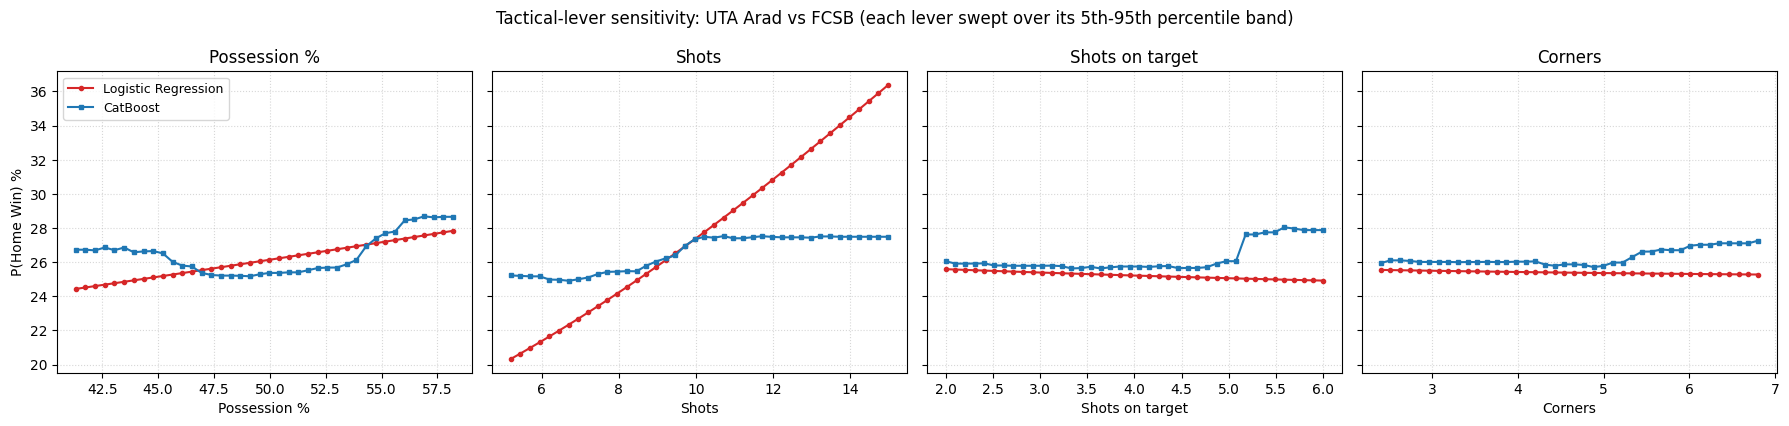

Per-lever swing for the figure (single UTA Arad vs FCSB fixture), pp:
Lever                    LR   CatBoost
--------------------------------------
Possession %            3.4        3.5
Shots                  16.0        2.6
Shots on target         0.7        2.4
Corners                 0.3        1.5


In [4]:
LEVERS = ["Home_Poss_5", "Home_Shots_5", "Home_SoT_5", "Home_Corners_5"]
LABELS = {"Home_Poss_5":"Possession %","Home_Shots_5":"Shots","Home_SoT_5":"Shots on target","Home_Corners_5":"Corners"}
bands = {lev: (float(train_df[lev].quantile(0.05)), float(train_df[lev].quantile(0.95))) for lev in LEVERS}

def sweep(model, lev, xs):
    out = []; idx = feature_idx[lev]
    for x in xs:
        v = base_vec.copy(); v[idx] = x
        out.append(float(model.predict_proba(pd.DataFrame([v], columns=feature_cols))[0,1])*100.0)
    return out

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3), sharey=True)
swings = {}
for ax, lev in zip(axes, LEVERS):
    lo, hi = bands[lev]; xs = np.linspace(lo, hi, 40)
    lr_curve = sweep(calibrated_lr, lev, xs); cat_curve = sweep(calibrated_cat, lev, xs)
    ax.plot(xs, lr_curve, color="#d62728", marker="o", markersize=3, label="Logistic Regression")
    ax.plot(xs, cat_curve, color="#1f77b4", marker="s", markersize=3, label="CatBoost")
    ax.set_title(LABELS[lev]); ax.set_xlabel(LABELS[lev]); ax.grid(True, linestyle=":", alpha=0.5)
    swings[lev] = (max(lr_curve)-min(lr_curve), max(cat_curve)-min(cat_curve))
axes[0].set_ylabel("P(Home Win) %"); axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle(f"Tactical-lever sensitivity: {HOME_TEAM} vs {AWAY_TEAM} (each lever swept over its 5th-95th percentile band)")
plt.tight_layout(); plt.show()

print("Per-lever swing for the figure (single UTA Arad vs FCSB fixture), pp:")
print(f"{'Lever':18s} {'LR':>8s} {'CatBoost':>10s}"); print("-"*38)
for lev in LEVERS:
    print(f"{LABELS[lev]:18s} {swings[lev][0]:8.1f} {swings[lev][1]:10.1f}")


In [5]:
# Holdout-AVERAGED swings: these match the numbers quoted in the thesis text
# (LR shots ~17 pp; CatBoost roughly 6.7 / 5.6 / 5.2 / 2.8 across the levers).
print("Holdout-averaged swings (match the thesis text), pp:")
print(f"{'Lever':18s} {'LR':>8s} {'CatBoost':>10s}"); print("-"*38)
for lev in LEVERS:
    lo, hi = bands[lev]; xs = np.linspace(lo, hi, 25)
    lr_c, cat_c = [], []
    for x in xs:
        f = test_df.copy(); f[lev] = x
        lr_c.append(float(calibrated_lr.predict_proba(f[feature_cols])[:,1].mean())*100)
        cat_c.append(float(calibrated_cat.predict_proba(f[feature_cols])[:,1].mean())*100)
    print(f"{LABELS[lev]:18s} {max(lr_c)-min(lr_c):8.1f} {max(cat_c)-min(cat_c):10.1f}")


Holdout-averaged swings (match the thesis text), pp:
Lever                    LR   CatBoost
--------------------------------------


Possession %            4.0        6.6


Shots                  17.2        5.5


Shots on target         1.1        4.9


Corners                 0.1        2.6
